In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pymc as pm
import sklearn
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from pymc import Bernoulli, Data, Deterministic, MutableData, fit, math, sample, sample_prior_predictive
from sklearn.metrics import accuracy_score, roc_auc_score


from pybandits.model import BayesianLogisticRegression, BayesianNeuralNetwork


%load_ext autoreload
%autoreload 2


In [19]:
def plot_map(value, grid, x_test, pred, metric):
    cmap = plt.get_cmap('coolwarm')

    fig, ax = plt.subplots(figsize=(10, 6))

    # Create the contour plot
    contour = ax.contourf(*grid, value.reshape(100, 100), cmap=cmap)

    # Scatter plot for the test points
    ax.scatter(x_test[pred == 0, 0], x_test[pred == 0, 1], label='Class 0')
    ax.scatter(x_test[pred == 1, 0], x_test[pred == 1, 1], color='r', label='Class 1')

    # Add a colorbar
    cbar = plt.colorbar(contour, ax=ax)
    cbar.ax.set_ylabel(f'Posterior predictive {metric} probability of class label = 1')

    # Set axis limits and labels
    ax.set(xlim=(-3, 3), ylim=(-3, 3), xlabel='X', ylabel='Y')

    # Add a legend
    ax.legend()

    plt.show()


## Generate data

In [3]:
X, Y = make_moons(noise=0.2, random_state=0, n_samples=1000)
X = scale(X)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=.5)
y_train = y_train.tolist()
y_test = y_test.tolist()


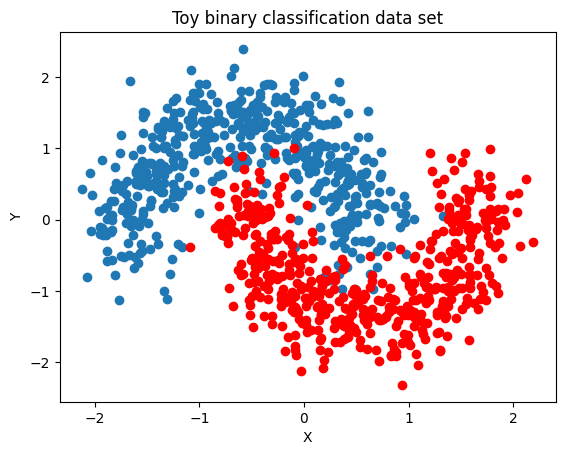

In [4]:

fig, ax = plt.subplots()
ax.scatter(X[Y==0, 0], X[Y==0, 1], label='Class 0')
ax.scatter(X[Y==1, 0], X[Y==1, 1], color='r', label='Class 1')
ax.set(xlabel='X', ylabel='Y', title='Toy binary classification data set');

## Using Bayesian logistic regression

In [5]:
blr = BayesianLogisticRegression.cold_start(n_features=2,update_method ="VI", update_kwargs={"fit": {"n": 20000}})

In [6]:

blr.update(x_train, y_train)

Finished [100%]: Average Loss = 282.74


In [7]:
dummy_out = [1] * len(y_test)
_model = blr.create_model(x_test , dummy_out, is_sampelwise=True)
with _model:
    samples = pm.sample_prior_predictive(samples=500)

Sampling: [b0, out, w0]


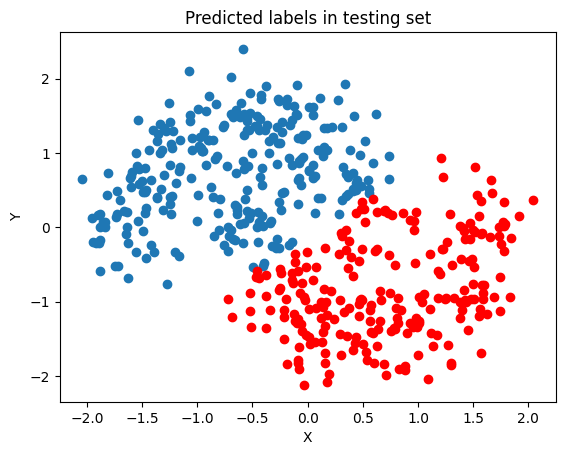

In [8]:
pred_proba = samples['prior_predictive']['out'].squeeze().values.mean(axis=0)
pred =  pred_proba > 0.5

fig, ax = plt.subplots()
ax.scatter(x_test[pred==0, 0], x_test[pred==0, 1])
ax.scatter(x_test[pred==1, 0], x_test[pred==1, 1], color='r')
ax.set(title='Predicted labels in testing set', xlabel='X', ylabel='Y');


In [10]:
# Calculate accuracy
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy: {accuracy}')

# Calculate AUC
auc = roc_auc_score(y_test, pred_proba)
print(f'AUC: {auc}')

Accuracy: 0.836
AUC: 0.9273095325726904


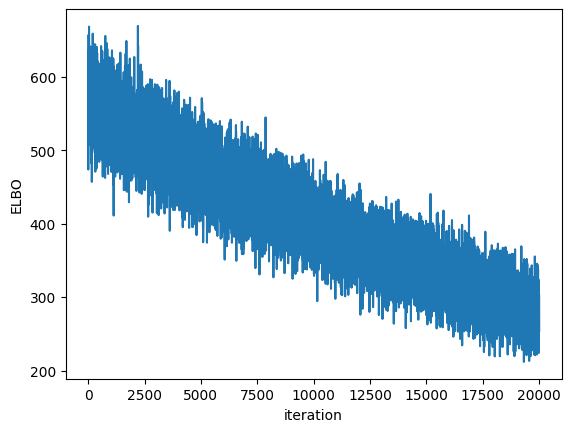

In [11]:
plt.plot(blr._approx.hist)
plt.ylabel('ELBO')
plt.xlabel('iteration')
plt.show()


### Predictions + uncertainty map

In [12]:
grid = np.mgrid[-3:3:100j,-3:3:100j].astype(float)
grid_2d = grid.reshape(2, -1).T
grid_label = np.ones(grid_2d.shape[0], dtype=np.int8).tolist()

In [17]:
_model = blr.create_model(grid_2d , grid_label, is_sampelwise=True)
with _model:
    samples = pm.sample_prior_predictive(samples=500)

Sampling: [b0, out, w0]


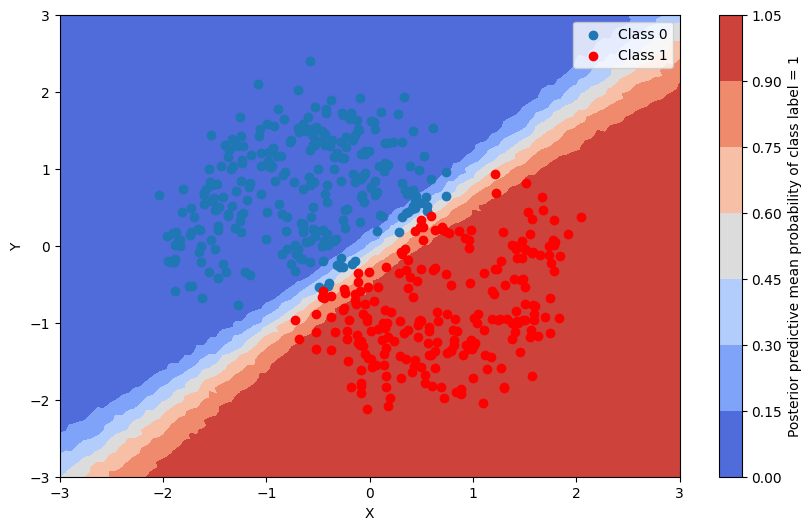

In [20]:
prob  = samples['prior_predictive']['out'].squeeze().values.mean(axis=0) 
plot_map(prob, grid, x_test, pred, 'mean')

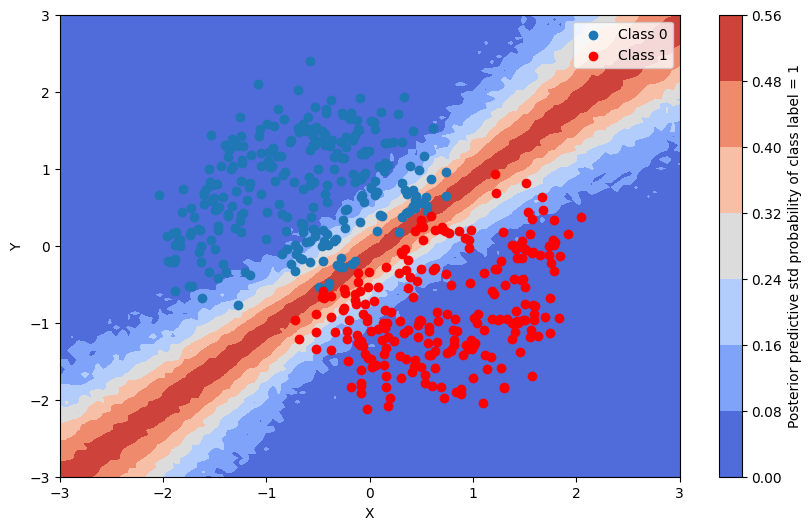

In [21]:
std  = samples['prior_predictive']['out'].squeeze().values.std(axis=0) 
plot_map(std, grid, x_test, pred, "std")


## Using Bayesian Neural Network

In [22]:
dist_params_init = {'mu' : 0, 'sigma' : 1, 'nu': 5}
bnn = BayesianNeuralNetwork.cold_start(dim_list=[2, 5, 5 ],update_method ="VI", dist_params_init= dist_params_init, update_kwargs={'fit': {'n': 100000}}, )


In [23]:
bnn.update(x_train, y_train)

Finished [100%]: Average Loss = 123.11


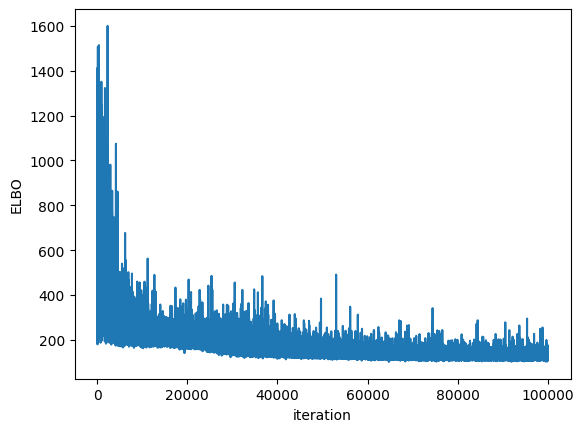

In [24]:
plt.plot(bnn._approx.hist)
plt.ylabel('ELBO')
plt.xlabel('iteration')
plt.show()


Sampling: [b0, b1, b2, out, w0, w1, w2]


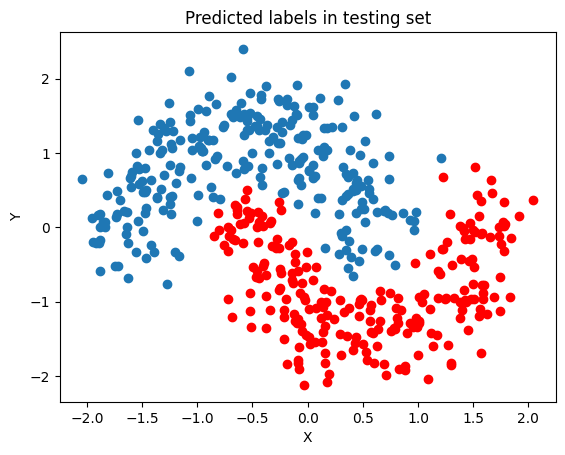

In [26]:
dummy_out = [1] * len(y_test)
_model = bnn.create_model(x_test , dummy_out, is_sampelwise=True)
with _model:
    samples = pm.sample_prior_predictive(samples=500)

pred_proba = samples['prior_predictive']['out'].squeeze().values.mean(axis=0)
pred = pred_proba > 0.5

fig, ax = plt.subplots()
ax.scatter(x_test[pred==0, 0], x_test[pred==0, 1])
ax.scatter(x_test[pred==1, 0], x_test[pred==1, 1], color='r')
ax.set(title='Predicted labels in testing set', xlabel='X', ylabel='Y');

In [27]:
# Calculate accuracy
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy: {accuracy}')

# Calculate AUC
auc = roc_auc_score(y_test, pred_proba)
print(f'AUC: {auc}')


Accuracy: 0.972
AUC: 0.9978396889152037


### Predictions + uncertainty map

In [ ]:
grid = np.mgrid[-3:3:100j,-3:3:100j].astype(float)
grid_2d = grid.reshape(2, -1).T
grid_label = np.ones(grid_2d.shape[0], dtype=np.int8).tolist()

In [43]:
_model = bnn.create_model(grid_2d , grid_label, is_sampelwise=True)
with _model:
    samples = pm.sample_prior_predictive(samples=500)


Sampling: [b0, b1, b2, out, w0, w1, w2]


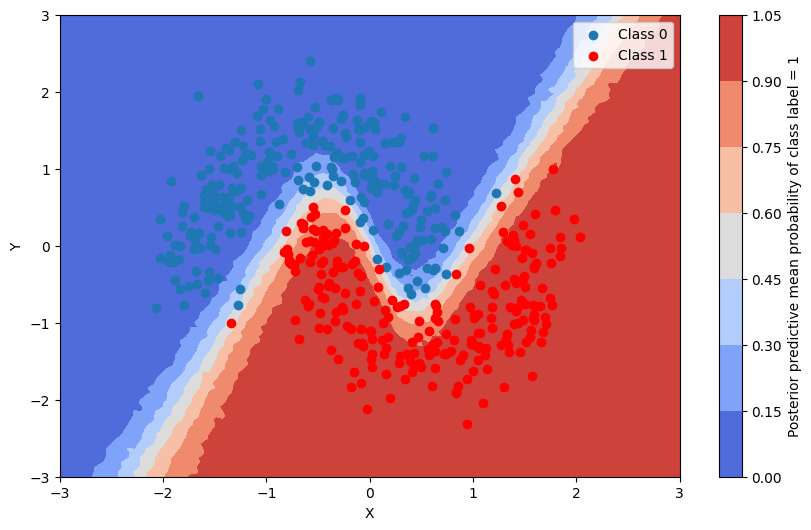

In [44]:
mean  = samples['prior_predictive']['out'].squeeze().values.mean(axis=0) 
plot_map(mean, grid, x_test, pred, "mean")


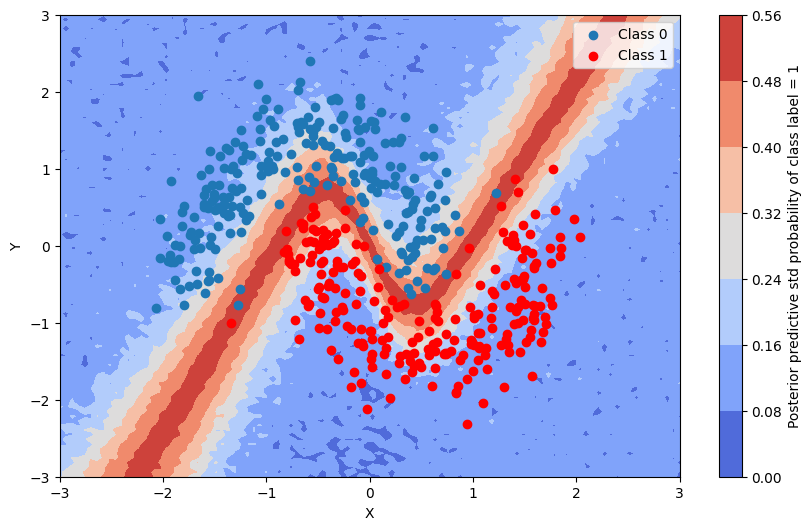

In [45]:
std  = samples['prior_predictive']['out'].squeeze().values.std(axis=0) 
plot_map(std, grid, x_test, pred,"std")
